# Problem Questions
1. Which Geography generates highest sales (Amount)? 
2. Which Sales Person performs best?
3. Which Product sells most?
4. Does Units affect Amount?
5. Are there any outliers in Amount?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv("awesome.csv")

In [2]:
df.head(5)

,Sales Person,Geography,Product,Amount,Units
0,Ram Mahesh,New Zealand,70% Dark Bites,1624,114
1,Brien Boise,USA,Choco Coated Almonds,6706,459
2,Husein Augar,USA,Almond Choco,959,147
3,Carla Molina,Canada,Drinking Coco,9632,288
4,Curtice Advani,UK,White Choc,2100,414


In [3]:
df.describe()

,Amount,Units
count,300.000000,300.000000
mean,4136.230000,152.200000
std,3124.832629,118.099499
min,0.000000,0.000000
25%,1652.000000,54.000000
50%,3437.000000,124.500000
75%,6179.250000,220.500000
max,16184.000000,525.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sales Person  300 non-null    object
 1   Geography     300 non-null    object
 2   Product       300 non-null    object
 3   Amount        300 non-null    int64 
 4   Units         300 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 11.8+ KB


*Univariate Analysis*

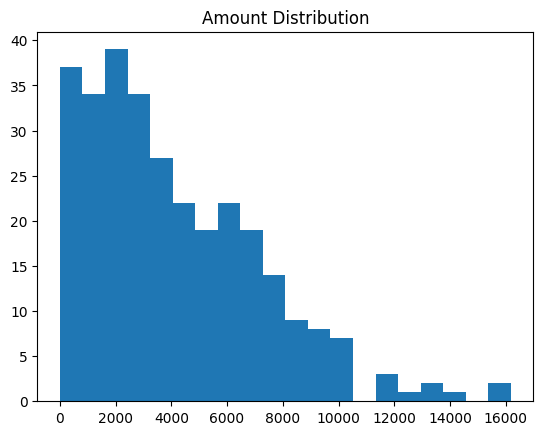

In [5]:
#Amount Distribution
plt.hist(df["Amount"], bins=20)
plt.title("Amount Distribution")
plt.show()

*Geography Count*

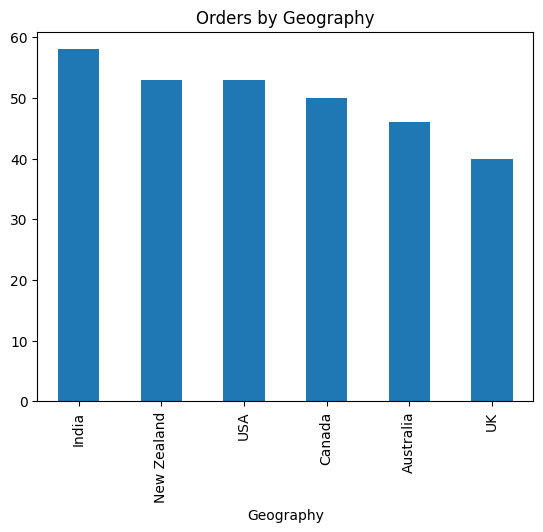

In [8]:
df["Geography"].value_counts().plot(kind="bar")
plt.title("Orders by Geography")
plt.show()

*Bivariate Analysis*

In [9]:
#Geography vs Amount

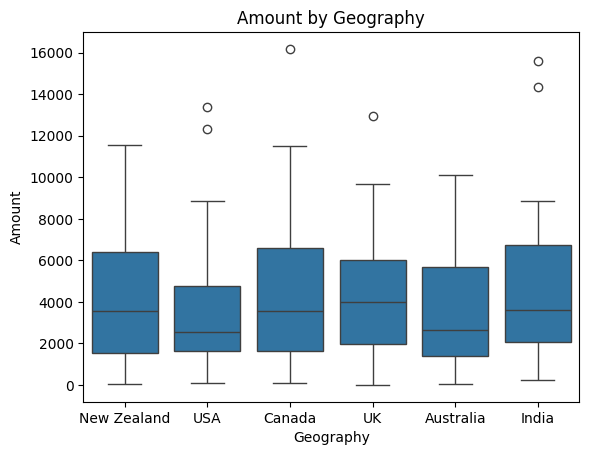

In [11]:
sns.boxplot(x="Geography", y="Amount", data=df)
plt.title("Amount by Geography")
plt.show()

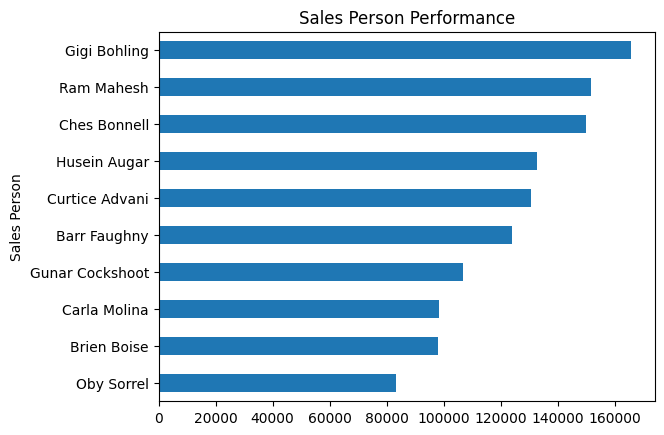

In [12]:
#Sales Person Performance
df.groupby("Sales Person")["Amount"].sum().sort_values().plot(kind="barh")
plt.title("Sales Person Performance")
plt.show()

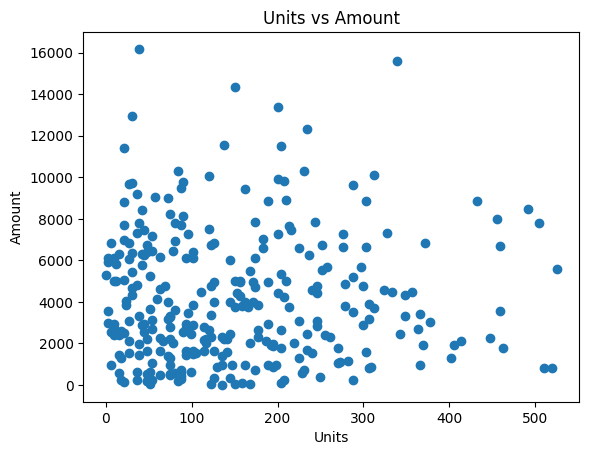

In [13]:
#Units vs Amount (Relationship)
plt.scatter(df["Units"], df["Amount"])
plt.xlabel("Units")
plt.ylabel("Amount")
plt.title("Units vs Amount")
plt.show()

In [14]:
#Correlation
df[["Units", "Amount"]].corr()

,Units,Amount
Units,1.000000,0.026546
Amount,0.026546,1.000000


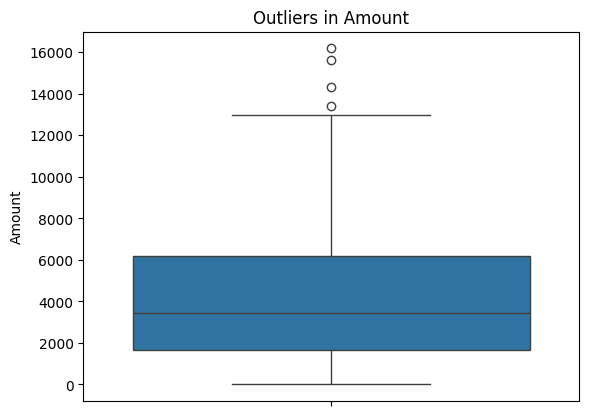

In [15]:
#Outlier Detection
sns.boxplot(df["Amount"])
plt.title("Outliers in Amount")
plt.show()

Hypothesis Testing (USA vs UK)

In [17]:
from scipy.stats import ttest_ind
# Create groups
usa = df[df["Geography"] == "USA"]["Amount"]
uk = df[df["Geography"] == "UK"]["Amount"]

# Perform T-test
t_stat, p_value = ttest_ind(usa, uk)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.266181194735398
P-value: 0.20867995273438184


In [18]:
if p_value <= 0.05:
    print("Reject Null Hypothesis → Significant difference")
else:
    print("Fail to Reject Null Hypothesis → No significant difference")

Fail to Reject Null Hypothesis → No significant difference


Confidence Interval (Mean Amount)

In [21]:
# Amount column
data = df["Amount"]

# Calculate values
mean = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)

# 95% Confidence Interval
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))

print("Mean:", mean)
print("95% Confidence Interval:", ci)

Mean: 4136.23
95% Confidence Interval: (3781.1912901118712, 4491.268709888128)


In [22]:
# Difference of means
diff_mean = np.mean(usa) - np.mean(uk)

# Standard error
se = np.sqrt(np.var(usa, ddof=1)/len(usa) + np.var(uk, ddof=1)/len(uk))

# Confidence Interval for difference
ci_diff = stats.t.interval(0.95, df=len(usa)+len(uk)-2, loc=diff_mean, scale=se)

print("Difference CI:", ci_diff)

Difference CI: (-1968.7750706989195, 440.72790088759893)


In [23]:
if ci_diff[0] <= 0 <= ci_diff[1]:
    print("No significant difference (CI includes 0)")
else:
    print("Significant difference (CI does not include 0)")

No significant difference (CI includes 0)
